# The Yule Process (Pure Birth)

The **Yule process** is a continuous-time model of a growing population. Every individual currently alive independently gives birth at rate `birth_rate`, and nothing ever dies -- so with `n` individuals present, the next birth arrives at total rate `n * birth_rate`.

In [9]:
from symbulate import *
from math import exp

## Sample paths

Starting from a single individual, the population climbs by one at each birth. Because more individuals means faster births, the growth accelerates -- the paths curve upward (exponentially).

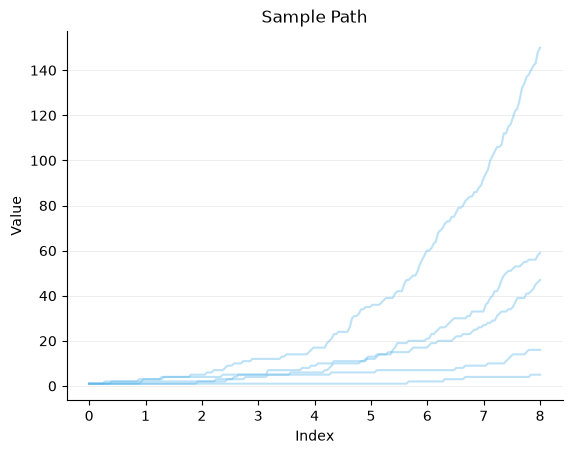

In [10]:
process = YuleProcess(birth_rate=0.5)
process.sim(5).plot(tmin=0, tmax=8)

## The population grows exponentially on average

Started from one individual, the mean population size at time `t` is `exp(birth_rate * t)`. Simulating the population at several times confirms the exponential growth.

In [11]:
lam = 0.5
for t in [1, 2, 3, 4]:
    sims = [process.draw()(t) for _ in range(1500)]
    print(f"t = {t}:  simulated mean {sum(sims) / len(sims):5.2f}   e^(lam*t) = {exp(lam * t):5.2f}")

t = 1:  simulated mean  1.66   e^(lam*t) =  1.65
t = 2:  simulated mean  2.73   e^(lam*t) =  2.72
t = 3:  simulated mean  4.55   e^(lam*t) =  4.48
t = 4:  simulated mean  7.76   e^(lam*t) =  7.39


## The population size at a fixed time is geometric

Started from one individual, the population size at time `t` follows a **geometric** distribution with success probability `exp(-birth_rate * t)`: `P(N = k) = p * (1 - p)**(k - 1)` for `k = 1, 2, 3, ...`. Here `t = 2`, so `p = exp(-1) ~ 0.368`.

In [12]:
p = exp(-lam * 2)
counts = [process.draw()(2) for _ in range(2000)]
for k in range(1, 7):
    empirical = sum(c == k for c in counts) / len(counts)
    geometric = p * (1 - p) ** (k - 1)
    print(f"P(N = {k}):  empirical {empirical:.3f}   geometric {geometric:.3f}")

P(N = 1):  empirical 0.375   geometric 0.368
P(N = 2):  empirical 0.228   geometric 0.233
P(N = 3):  empirical 0.145   geometric 0.147
P(N = 4):  empirical 0.082   geometric 0.093
P(N = 5):  empirical 0.055   geometric 0.059
P(N = 6):  empirical 0.040   geometric 0.037
